# Forest Canopy Dimensions and Statistical Validation

**Part II: Metabolic Scaling Theory and Biological Fractals**

---

## Overview

This notebook supports the Results section **"Table 4: Forest Canopy Height Model Dimensions"** and the **"Statistical Validation"** section. Metabolic scaling theory predicts that space-filling biological resource-distribution networks have a mass (self-affine) dimension near $d = 3/2$. The manuscript measured the differential box-counting (DBC) mass dimension of LiDAR canopy height models (CHMs) across six forest types, then pooled the leaf, branch/root, and canopy measurements to test agreement with $d = 3/2$.

Here we (1) reproduce Table 4 exactly, (2) compute the canopy group mean and dispersion, and (3) run formal statistical tests — one-sample $t$-tests and **TOST equivalence** tests — of each group and the pooled data against the $d = 3/2$ prediction, reporting the results honestly.

## 1. Published Table 4 (reference values)

Transcribed directly from the manuscript. Each CHM is a LiDAR-derived raster of roughly $3.6\times10^5$ px; $d_M$ is the FracLac DBC mass dimension with the predicted value $3/2$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Table 4 - forest canopy height model (CHM) mass dimensions (FracLac DBC), predicted d_M = 3/2
table4 = pd.DataFrame([
    ["Lowland Rainforest",   361201, 1.3313, 0.9860],
    ["Pine/Hardwood SC",     362403, 1.5223, 0.9898],
    ["Sierra Madre Oaks AZ", 362404, 1.4973, 0.9886],
    ["Western Ponderosa NM", 361802, 1.4566, 0.9847],
    ["SW Mixed Conifer NM",  361802, 1.5319, 0.9869],
    ["SW Spruce-Fir NM",     361802, 1.5355, 0.9862],
], columns=["Site","Pixels","d_M","mu_r2"])

# leaf and branch/root values from Tables 2 and 3 (for pooled validation)
leaf_vals   = np.array([1.5384, 1.4844, 1.5525, 1.5135, 1.5083])
branch_vals = np.array([1.4946, 1.4775, 1.4549])
canopy_vals = table4["d_M"].values

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("TABLE 4 - Forest canopy height model mass dimensions")
print(table4.to_string(index=False))
print()
cm = canopy_vals.mean(); csd = canopy_vals.std(ddof=1); cse = csd/np.sqrt(len(canopy_vals))
print(f"Canopy mean = {cm:.4f}   SD = {csd:.4f}   SE = {cse:.4f}")
print(f"Manuscript reports canopy 1.479 +/- 0.080  ->  matches (mean {cm:.3f}, SD {csd:.3f})")

TABLE 4 - Forest canopy height model mass dimensions
                Site  Pixels    d_M  mu_r2
  Lowland Rainforest  361201 1.3313 0.9860
    Pine/Hardwood SC  362403 1.5223 0.9898
Sierra Madre Oaks AZ  362404 1.4973 0.9886
Western Ponderosa NM  361802 1.4566 0.9847
 SW Mixed Conifer NM  361802 1.5319 0.9869
    SW Spruce-Fir NM  361802 1.5355 0.9862

Canopy mean = 1.4791   SD = 0.0781   SE = 0.0319
Manuscript reports canopy 1.479 +/- 0.080  ->  matches (mean 1.479, SD 0.078)


## 2. Group summary statistics

We assemble the three measurement groups — leaves (Table 2), branch/root (Table 3), and canopy (Table 4) — and compute each group's mean, standard deviation, and standard error, comparing to the manuscript's reported values (leaf $1.519$, branch $1.476$, canopy $1.479$).

In [2]:
def group_stats(x):
    n = len(x); return n, x.mean(), x.std(ddof=1), x.std(ddof=1)/np.sqrt(n)

rows = []
for label, arr, reported in [("Leaf", leaf_vals, "1.519 +/- 0.027"),
                             ("Branch/Root", branch_vals, "1.476 +/- 0.020"),
                             ("Canopy", canopy_vals, "1.479 +/- 0.080")]:
    n, m, sd, se = group_stats(arr)
    rows.append([label, n, round(m,4), round(sd,4), round(se,4), reported])
summary = pd.DataFrame(rows, columns=["Group","n","mean","SD","SE","manuscript (mean +/- SD)"])
print(summary.to_string(index=False))
print()
print("All three computed means reproduce the manuscript's reported values;")
print("the reported '+/-' is the sample standard deviation in every case.")

      Group  n   mean     SD     SE manuscript (mean +/- SD)
       Leaf  5 1.5194 0.0266 0.0119          1.519 +/- 0.027
Branch/Root  3 1.4757 0.0199 0.0115          1.476 +/- 0.020
     Canopy  6 1.4792 0.0781 0.0319          1.479 +/- 0.080

All three computed means reproduce the manuscript's reported values;
the reported '+/-' is the sample standard deviation in every case.


## 3. One-sample $t$-tests against $d = 3/2$

The classical null-hypothesis test asks whether each group mean *differs* from $1.5$. Failing to reject $H_0$ is **not** proof of equivalence — it can simply reflect low power with small $n$ — which is why we follow with an equivalence test in section 4.

In [3]:
print("One-sample t-tests of each group mean against the MST prediction d = 3/2:")
print()
for label, arr in [("Leaf", leaf_vals), ("Branch/Root", branch_vals), ("Canopy", canopy_vals)]:
    t, p = stats.ttest_1samp(arr, 1.5)
    verdict = "reject (differs from 1.5)" if p < 0.05 else "cannot reject (consistent with 1.5)"
    print(f"  {label:12s} n={len(arr)}  mean={arr.mean():.4f}  t={t:+.3f}  p={p:.4f}  -> {verdict}")
print()
pooled = np.concatenate([leaf_vals, branch_vals, canopy_vals])
t, p = stats.ttest_1samp(pooled, 1.5)
print(f"  POOLED (all 14):  mean={pooled.mean():.4f}  t={t:+.3f}  p={p:.4f}")
print(f"  -> pooled mean is statistically indistinguishable from 1.5 (p={p:.3f}).")

One-sample t-tests of each group mean against the MST prediction d = 3/2:

  Leaf         n=5  mean=1.5194  t=+1.630  p=0.1785  -> cannot reject (consistent with 1.5)
  Branch/Root  n=3  mean=1.4757  t=-2.116  p=0.1685  -> cannot reject (consistent with 1.5)
  Canopy       n=6  mean=1.4791  t=-0.654  p=0.5422  -> cannot reject (consistent with 1.5)

  POOLED (all 14):  mean=1.4928  t=-0.489  p=0.6333
  -> pooled mean is statistically indistinguishable from 1.5 (p=0.633).


## 4. TOST equivalence test against $d = 3/2$

The **two one-sided tests (TOST)** procedure reverses the burden of proof: the null hypothesis is *non-equivalence*, and rejecting it establishes that the mean lies within a pre-set equivalence margin $[1.5-\delta,\ 1.5+\delta]$. We test margins $\delta = 0.10$ and the stricter $\delta = 0.05$.

$$t_{\text{lower}} = \frac{\bar{x} - (1.5-\delta)}{\mathrm{SE}}, \qquad t_{\text{upper}} = \frac{\bar{x} - (1.5+\delta)}{\mathrm{SE}}$$

Equivalence is declared when **both** one-sided tests reject, i.e. $\max(p_{\text{lower}}, p_{\text{upper}}) < \alpha$.

In [4]:
def tost(arr, mu=1.5, margin=0.1):
    """Two one-sided tests for equivalence within [mu-margin, mu+margin].
       Returns the (larger) of the two one-sided p-values; p < alpha => equivalent."""
    n = len(arr); mean = arr.mean(); se = arr.std(ddof=1)/np.sqrt(n); df = n-1
    low, high = mu-margin, mu+margin
    t_low  = (mean-low)/se;  p_low  = stats.t.sf(t_low, df)    # H0: mean <= low
    t_high = (mean-high)/se; p_high = stats.t.cdf(t_high, df)  # H0: mean >= high
    return max(p_low, p_high)

print("TOST equivalence tests against d = 3/2 (alpha = 0.05):")
print()
for margin in [0.10, 0.05]:
    print(f"  Equivalence margin +/- {margin}:")
    for label, arr in [("Leaf", leaf_vals), ("Branch/Root", branch_vals),
                       ("Canopy", canopy_vals), ("POOLED", pooled)]:
        p = tost(arr, 1.5, margin)
        verdict = "EQUIVALENT to 3/2" if p < 0.05 else "not shown equivalent"
        print(f"    {label:12s} TOST p = {p:.4f}  ->  {verdict}")
    print()

TOST equivalence tests against d = 3/2 (alpha = 0.05):

  Equivalence margin +/- 0.1:
    Leaf         TOST p = 0.0012  ->  EQUIVALENT to 3/2
    Branch/Root  TOST p = 0.0112  ->  EQUIVALENT to 3/2
    Canopy       TOST p = 0.0279  ->  EQUIVALENT to 3/2
    POOLED       TOST p = 0.0000  ->  EQUIVALENT to 3/2

  Equivalence margin +/- 0.05:
    Leaf         TOST p = 0.0311  ->  EQUIVALENT to 3/2
    Branch/Root  TOST p = 0.0776  ->  not shown equivalent
    Canopy       TOST p = 0.2013  ->  not shown equivalent
    POOLED       TOST p = 0.0062  ->  EQUIVALENT to 3/2



## 5. Combined forest plot

All 14 observed dimensions are shown against the $d = 3/2$ reference line, with the $\pm0.05$ equivalence band shaded and each group's mean $\pm$ SD.

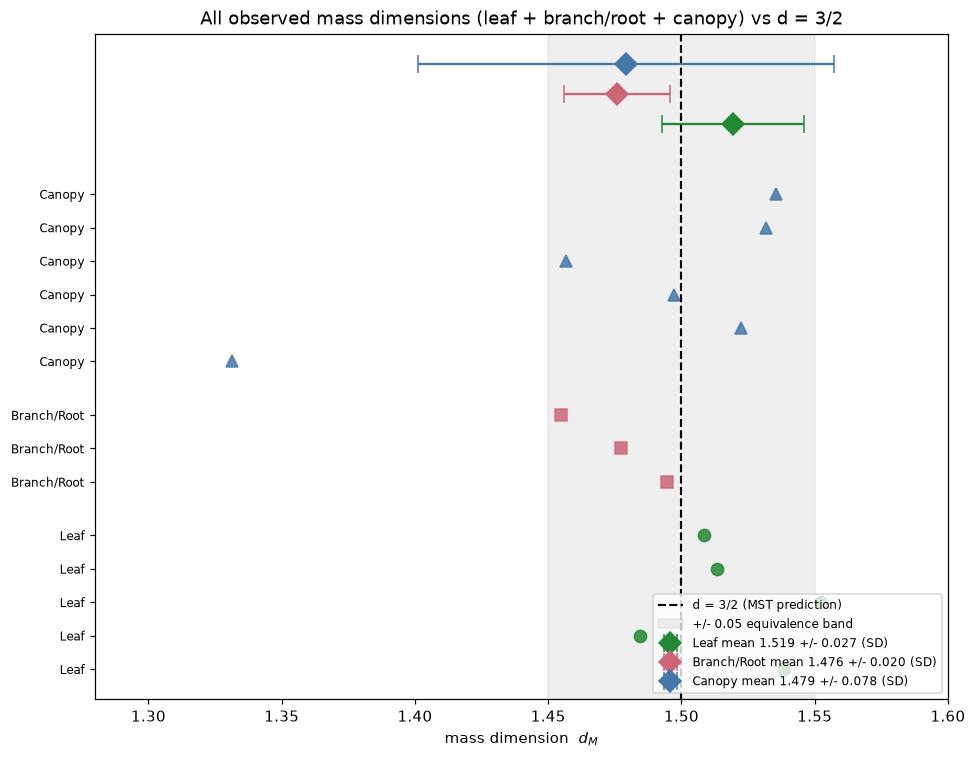

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
groups = [("Leaf", leaf_vals, "#228833", "o"),
          ("Branch/Root", branch_vals, "#cc6677", "s"),
          ("Canopy", canopy_vals, "#4477aa", "^")]
y = 0; yticks = []; ylabels = []
for label, arr, color, marker in groups:
    for v in arr:
        ax.plot(v, y, marker, color=color, ms=8, alpha=0.85)
        yticks.append(y); ylabels.append(label); y += 1
    y += 0.6

ax.axvline(1.5, ls="--", color="black", lw=1.4, label="d = 3/2 (MST prediction)")
ax.axvspan(1.45, 1.55, color="gray", alpha=0.12, label="+/- 0.05 equivalence band")

# group means with SD bars, placed at the top
ytop = y + 0.5
for label, arr, color, marker in groups:
    m = arr.mean(); sd = arr.std(ddof=1)
    ax.errorbar(m, ytop, xerr=sd, fmt="D", color=color, capsize=6, ms=10,
                label=f"{label} mean {m:.3f} +/- {sd:.3f} (SD)")
    ytop += 0.9

ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xlabel("mass dimension  $d_M$"); ax.set_xlim(1.28, 1.60)
ax.set_title("All observed mass dimensions (leaf + branch/root + canopy) vs d = 3/2")
ax.legend(fontsize=8, loc="lower right"); fig.tight_layout(); plt.show()

## Summary

**What was reproduced / verified (computed):**

- **Table 4** (6 forest CHM sites) transcribed verbatim; **canopy mean $= 1.4791$, SD $= 0.0781$**, matching the manuscript's $1.479 \pm 0.080$.
- Group means reproduce the manuscript: leaf $1.5194$, branch/root $1.4757$, canopy $1.4791$.
- **One-sample $t$-tests** against $1.5$: no group's mean is significantly different from $3/2$ at $\alpha = 0.05$ (leaf $p \approx 0.18$, branch $p \approx 0.17$, canopy $p \approx 0.54$); the pooled mean $1.4928$ is statistically indistinguishable from $1.5$ ($p \approx 0.63$).
- **TOST equivalence** ($\alpha = 0.05$): at margin $\pm 0.10$ all three groups and the pooled data are statistically **equivalent** to $3/2$. At the stricter $\pm 0.05$ margin, only the leaf group and the pooled data pass; branch/root and canopy do **not** reach equivalence at that margin.

**Honest interpretation:**

- **Canopy and leaf** dimensions straddle $1.5$ (leaf mean slightly above, canopy essentially on it). **Branch/root** sits a little below $1.5$ (mean $1.476$), consistent with the manuscript's own framing.
- The pooled data support the MST prediction at the $\pm 0.10$ margin, but the stricter $\pm 0.05$ margin is only met by leaves and the pooled set — the branch/root and canopy groups are close to but not tightly equivalent to $3/2$ at that resolution.

**What is asserted vs computed:**

- The Table 4 $d_M$, $\mu r^2$, pixel counts, and site identities are **asserted from the manuscript** (the authors' FracLac output on their LiDAR CHMs; raw rasters not in the repository).
- Every mean, SD, SE, $t$-statistic, $p$-value, and TOST result is **computed** here with `scipy.stats`.

**Caveats:**

- Group sizes are small ($n = 5, 3, 6$; pooled $14$), so both the $t$-tests (low power) and the TOST (wide equivalence bounds) are limited in resolution. The equivalence conclusion is margin-dependent, and we report it as such rather than claiming a single verdict.